In [7]:
import os
import gc
import glob
import numpy as np
import rasterio
from rasterio.mask import mask
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, f1_score
from datetime import datetime
from tqdm import tqdm
import geopandas as gpd
from shapely.geometry import mapping
import ee
import base64
from IPython.display import display, HTML
import folium
from PIL import Image
import io
import branca.colormap as cm


# =====================================================================
# STEP 1: HARDWARE OPTIMIZATION & ENVIRONMENT SETUP
# =====================================================================
print(f"\n{'#'*70}\n STEP 1: SYSTEM INITIALIZATION & GEE AUTH\n{'#'*70}")

# Strict Threading Overrides to prevent WSL CPU thrashing
os.environ.update({
    "OMP_NUM_THREADS": "1", 
    "OPENBLAS_NUM_THREADS": "1", 
    "MKL_NUM_THREADS": "1", 
    "VECLIB_MAXIMUM_THREADS": "1", 
    "NUMEXPR_NUM_THREADS": "1"
})

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"[INFO] Hardware execution targeted to: {device}")

# Base directories routed through WSL Rclone mount
data_dir = "/home/daves/google_drive/Pessoal/Notebooks/Queimadas/Production/Data"
sliced_dir = "/home/daves/google_drive/Pessoal/Notebooks/Queimadas/Production/Sliced_Data"
model_dir = "/home/daves/google_drive/Pessoal/Notebooks/Queimadas/Production/Models"

os.makedirs(data_dir, exist_ok=True)
os.makedirs(sliced_dir, exist_ok=True)
os.makedirs(model_dir, exist_ok=True)

# =====================================================================
# EARTH ENGINE AUTHENTICATION & PROJECT ROUTING
# =====================================================================
GCP_PROJECT_ID = 'indigo-syntax-420618'


# Authenticate and Initialize Earth Engine
ee.Authenticate(auth_mode='localhost')
try:
    ee.Initialize(project=GCP_PROJECT_ID)
    print(f"[SUCCESS] Earth Engine Initialized on project: {GCP_PROJECT_ID}.")
except Exception as e:
    print(f"[WARNING] Earth Engine not initialized. Triggering notebook authentication...")
    
    ee.Authenticate() 
    ee.Initialize(project=GCP_PROJECT_ID)
    print(f"[SUCCESS] Earth Engine Authenticated and Initialized on project: {GCP_PROJECT_ID}.")


######################################################################
 STEP 1: SYSTEM INITIALIZATION & GEE AUTH
######################################################################
[INFO] Hardware execution targeted to: cuda
[SUCCESS] Earth Engine Initialized on project: indigo-syntax-420618.


In [2]:
# =====================================================================
# STEP 2: GOOGLE EARTH ENGINE ASYNCHRONOUS BATCH QUEUEING (1 KM)
# =====================================================================
print(f"\n{'#'*70}\n STEP 2: CHECKING FILES & QUEUEING 1 KM GEE EXPORTS TO DRIVE\n{'#'*70}")

# Define the precise spatial bounding box for Mato Grosso
mt_state = ee.FeatureCollection("FAO/GAUL/2015/level1").filter(ee.Filter.eq('ADM1_NAME', 'Mato Grosso'))
roi_bounds = mt_state.geometry().bounds()
region_coords = roi_bounds.getInfo()['coordinates']

missing_files = 0
found_files = 0

# The GEE Asynchronous Export Function - SET TO 1 KM RESOLUTION (1000 meters)
def queue_export(image, description, file_prefix, scale=1000):
    ee.batch.Export.image.toDrive(
        image=image,
        description=description,
        folder='Data', # Ensure this matches your target Drive folder name exactly
        fileNamePrefix=file_prefix,
        region=region_coords,
        scale=scale,
        crs='EPSG:4326',
        maxPixels=1e13
    ).start()

# =====================================================================
# 1. STATIC VARIABLES (Exported once, year-independent)
# =====================================================================
print("--- Checking Static Topography & Infrastructure ---")

f_roads = os.path.join(data_dir, 'Infrastructure_Roads.tif')
if not os.path.exists(f_roads):
    print("  [MISSING] Queueing Infrastructure Roads export...")
    roads = ee.FeatureCollection("projects/sat-io/open-datasets/GRIP4/Central-South-America").filterBounds(roi_bounds)
    distance_to_roads = roads.distance(searchRadius=50000, maxError=100)
    queue_export(distance_to_roads, 'Infrastructure_Roads', 'Infrastructure_Roads')
    missing_files += 1
else:
    found_files += 1

f_dem = os.path.join(data_dir, 'Terrain_DEM.tif')
f_slope = os.path.join(data_dir, 'Terrain_Slope.tif')
f_aspect = os.path.join(data_dir, 'Terrain_Aspect.tif')
srtm = ee.Image("USGS/SRTMGL1_003")

if not os.path.exists(f_dem):
    print("  [MISSING] Queueing DEM export...")
    queue_export(srtm.select('elevation'), 'Terrain_DEM', 'Terrain_DEM')
    missing_files += 1
else: found_files += 1

if not os.path.exists(f_slope):
    print("  [MISSING] Queueing Slope export...")
    queue_export(ee.Terrain.slope(srtm), 'Terrain_Slope', 'Terrain_Slope')
    missing_files += 1
else: found_files += 1

if not os.path.exists(f_aspect):
    print("  [MISSING] Queueing Aspect export...")
    queue_export(ee.Terrain.aspect(srtm), 'Terrain_Aspect', 'Terrain_Aspect')
    missing_files += 1
else: found_files += 1

# =====================================================================
# 2. DYNAMIC VARIABLES (Exported per year)
# =====================================================================
years = range(2018, 2027)

for year in years:
    print(f"\n--- Checking Year {year} ---")
    start_date = f'{year}-01-01'
    end_date   = f'{year+1}-01-01'

    f_temp = os.path.join(data_dir, f'ERA5_Temp_{year}.tif')
    if not os.path.exists(f_temp):
        print(f"  [MISSING] Queueing Temperature for {year}...")
        era5_t = ee.ImageCollection("ECMWF/ERA5_LAND/DAILY_AGGR").filterBounds(roi_bounds).filterDate(start_date, end_date)
        queue_export(era5_t.select('temperature_2m').toBands(), f'ERA5_Temp_{year}', f'ERA5_Temp_{year}')
        missing_files += 1
    else: found_files += 1

    f_vpd = os.path.join(data_dir, f'ERA5_VPD_{year}.tif')
    if not os.path.exists(f_vpd):
        print(f"  [MISSING] Queueing VPD for {year}...")
        def compute_daily_vpd(image):
            t_k = image.select('temperature_2m')
            td_k = image.select('dewpoint_temperature_2m')
            t_c = t_k.subtract(273.15)
            td_c = td_k.subtract(273.15)
            es = t_c.divide(t_c.add(237.3)).multiply(17.27).exp().multiply(0.6108)
            ea = td_c.divide(td_c.add(237.3)).multiply(17.27).exp().multiply(0.6108)
            vpd = es.subtract(ea).max(ee.Image.constant(0)).rename('VPD')
            return vpd.copyProperties(image, ['system:time_start'])

        vpd_col = (ee.ImageCollection("ECMWF/ERA5_LAND/DAILY_AGGR")
                     .filterBounds(roi_bounds)
                     .filterDate(start_date, end_date)
                     .select(['temperature_2m', 'dewpoint_temperature_2m'])
                     .map(compute_daily_vpd))
        queue_export(vpd_col.toBands(), f'ERA5_VPD_{year}', f'ERA5_VPD_{year}')
        missing_files += 1
    else: found_files += 1

    f_evi = os.path.join(data_dir, f'MODIS_EVI_{year}.tif')
    if not os.path.exists(f_evi):
        print(f"  [MISSING] Queueing MODIS EVI for {year}...")
        evi_col = ee.ImageCollection("MODIS/061/MOD13A2").filterBounds(roi_bounds).filterDate(start_date, end_date).select('EVI')
        queue_export(evi_col.toBands(), f'MODIS_EVI_{year}', f'MODIS_EVI_{year}')
        missing_files += 1
    else: found_files += 1

    f_smap = os.path.join(data_dir, f'SMAP_SoilMoisture_{year}.tif')
    if not os.path.exists(f_smap):
        print(f"  [MISSING] Queueing SMAP Soil Moisture for {year}...")
        def fill_smap_gap(day_offset):
            d = ee.Date(start_date).advance(ee.Number(day_offset), 'day')
            daily = ee.ImageCollection("NASA/SMAP/SPL3SMP_E/006").filterBounds(roi_bounds).filterDate(d, d.advance(1, 'day')).select('soil_moisture_am')
            filled = ee.Image(ee.Algorithms.If(daily.size().gt(0), daily.mean(), ee.Image.constant(-9999))).rename('soil_moisture_am').toFloat()
            return filled.set('system:time_start', d.millis())

        start_ee = ee.Date(start_date)
        end_ee = ee.Date(end_date)
        n_days = end_ee.difference(start_ee, 'day')
        days_seq = ee.List.sequence(0, n_days.subtract(1))
        smap_col = ee.ImageCollection.fromImages(days_seq.map(fill_smap_gap))
        queue_export(smap_col.toBands(), f'SMAP_SoilMoisture_{year}', f'SMAP_SoilMoisture_{year}')
        missing_files += 1
    else: found_files += 1

    f_co = os.path.join(data_dir, f'Sentinel5P_CO_{year}.tif')
    if not os.path.exists(f_co):
        print(f"  [MISSING] Queueing Sentinel-5P CO for {year}...")
        def get_daily_co(day_offset):
            d = ee.Date(start_date).advance(ee.Number(day_offset), 'day')
            daily_col = ee.ImageCollection("COPERNICUS/S5P/OFFL/L3_CO").filterBounds(roi_bounds).filterDate(d, d.advance(1, 'day')).select('CO_column_number_density')
            daily_img = ee.Image(ee.Algorithms.If(daily_col.size().gt(0), daily_col.mean(), ee.Image.constant(0))).rename('CO').toFloat()
            return daily_img.set('system:time_start', d.millis())

        co_col = ee.ImageCollection.fromImages(days_seq.map(get_daily_co))
        queue_export(co_col.toBands(), f'Sentinel5P_CO_{year}', f'Sentinel5P_CO_{year}')
        missing_files += 1
    else: found_files += 1

    f_fire = os.path.join(data_dir, f'MODIS_Fire_{year}.tif')
    if not os.path.exists(f_fire):
        print(f"  [MISSING] Queueing Fire Data for {year}...")
        col = ee.ImageCollection("MODIS/061/MOD14A1").filterBounds(roi_bounds).filterDate(start_date, end_date).select('FireMask')
        queue_export(col.toBands(), f'MODIS_Fire_{year}', f'MODIS_Fire_{year}')
        missing_files += 1
    else: found_files += 1

    f_lulc = os.path.join(data_dir, f'MapBiomas_LULC_{year}.tif')
    if not os.path.exists(f_lulc):
        print(f"  [MISSING] Queueing Land Cover for {year}...")
        mb_year = min(year, 2023)
        mb_band = f'classification_{mb_year}'
        mapbiomas = ee.Image("projects/mapbiomas-public/assets/brazil/lulc/collection9/mapbiomas_collection90_integration_v1").select(mb_band).clip(mt_state)
        queue_export(mapbiomas, f'MapBiomas_LULC_{year}', f'MapBiomas_LULC_{year}')
        missing_files += 1
    else: found_files += 1

print("\n" + "=" * 60)
print("1 KM RESOLUTION INVENTORY (Exploratory Model):")
print("  Static  : Roads Distance, DEM, Slope, Aspect")
print("  Dynamic : Temperature, VPD, MODIS EVI, SMAP Soil Moisture,")
print("            MODIS Fire (target), MapBiomas LULC, Sentinel-5P CO")
print("-" * 60)
if missing_files == 0:
    print(f"[SUCCESS] ALL {found_files} REQUIRED FILES FOUND LOCALLY!")
    print("You are ready to proceed to Step 2 (Spatial Tiling).")
else:
    print(f"[STATUS] Found {found_files} files locally.")
    print(f"[ACTION] Queued {missing_files} missing files to Earth Engine at 1km Scale.")
    print("Monitor the GEE Task Manager at https://code.earthengine.google.com/tasks")
    print("Wait for Drive sync to complete before running Step 2.")
print("=" * 60 + "\n")


######################################################################
 STEP 2: CHECKING FILES & QUEUEING 1 KM GEE EXPORTS TO DRIVE
######################################################################
--- Checking Static Topography & Infrastructure ---

--- Checking Year 2018 ---

--- Checking Year 2019 ---

--- Checking Year 2020 ---

--- Checking Year 2021 ---

--- Checking Year 2022 ---

--- Checking Year 2023 ---

--- Checking Year 2024 ---

--- Checking Year 2025 ---

--- Checking Year 2026 ---

1 KM RESOLUTION INVENTORY (Exploratory Model):
  Static  : Roads Distance, DEM, Slope, Aspect
  Dynamic : Temperature, VPD, MODIS EVI, SMAP Soil Moisture,
            MODIS Fire (target), MapBiomas LULC, Sentinel-5P CO
------------------------------------------------------------
[SUCCESS] ALL 67 REQUIRED FILES FOUND LOCALLY!
You are ready to proceed to Step 2 (Spatial Tiling).



In [3]:
# =====================================================================
# STEP 3: SPATIAL TILING ALIGNMENT (128x128)
# =====================================================================
print(f"\n{'#'*70}\n STEP 3: SPATIAL TILING ALIGNMENT (128x128)\n{'#'*70}")

patch_size = 128
stride = 128
years = range(2018, 2027)

for y in years:
    check_file = os.path.join(sliced_dir, f"{'val' if y >= 2022 else 'train'}_patch_{y}_0.pt")
    requires_slicing = not os.path.exists(check_file)

    if requires_slicing:
        print(f"    -> Loading {y} spatial matrices into RAM (Excluding Precip)...")
        with rasterio.open(os.path.join(data_dir, f'ERA5_Temp_{y}.tif')) as src: t_raw = np.nan_to_num(src.read()).astype(np.float16)
        with rasterio.open(os.path.join(data_dir, f'ERA5_VPD_{y}.tif')) as src: v_raw = np.nan_to_num(src.read()).astype(np.float16)
        with rasterio.open(os.path.join(data_dir, f'SMAP_SoilMoisture_{y}.tif')) as src: sm_raw = np.nan_to_num(src.read()).astype(np.float16)
        with rasterio.open(os.path.join(data_dir, f'Sentinel5P_CO_{y}.tif')) as src: co_raw = np.nan_to_num(src.read()).astype(np.float16)
        with rasterio.open(os.path.join(data_dir, f'MODIS_EVI_{y}.tif')) as src: evi_raw = np.nan_to_num(src.read()).astype(np.float16)
        with rasterio.open(os.path.join(data_dir, f'MODIS_Fire_{y}.tif')) as src: f_raw = np.isin(np.nan_to_num(src.read()), [7,8,9]).astype(np.float16)
        
        with rasterio.open(os.path.join(data_dir, f'MapBiomas_LULC_{y}.tif')) as src: l_raw = np.nan_to_num(src.read()).astype(np.float16)
        with rasterio.open(os.path.join(data_dir, 'Infrastructure_Roads.tif')) as src: roads_static = np.nan_to_num(src.read()[0]).astype(np.float16)
        with rasterio.open(os.path.join(data_dir, 'Terrain_DEM.tif')) as src: dem_static = np.nan_to_num(src.read()[0]).astype(np.float16)
        with rasterio.open(os.path.join(data_dir, 'Terrain_Slope.tif')) as src: slope_static = np.nan_to_num(src.read()[0]).astype(np.float16)
        with rasterio.open(os.path.join(data_dir, 'Terrain_Aspect.tif')) as src: aspect_static = np.nan_to_num(src.read()[0]).astype(np.float16)

        # 1. TEMPORAL FIX: Find the minimum time WITHOUT EVI (EVI is a 16-day composite, usually 23 bands)
        min_t = min(t_raw.shape[0], v_raw.shape[0], sm_raw.shape[0], co_raw.shape[0], f_raw.shape[0])
        
        min_h = min(t_raw.shape[1], v_raw.shape[1], sm_raw.shape[1], co_raw.shape[1], evi_raw.shape[1], f_raw.shape[1], roads_static.shape[0], dem_static.shape[0])
        min_w = min(t_raw.shape[2], v_raw.shape[2], sm_raw.shape[2], co_raw.shape[2], evi_raw.shape[2], f_raw.shape[2], roads_static.shape[1], dem_static.shape[1])
        
        print(f"       -> Truncating daily dimensions to {min_t} days and {min_h}x{min_w} spatial grid.")

        # 2. INTERPOLATION: Stretch the 23 EVI bands to cover the full daily sequence (e.g., 365 days)
        if evi_raw.shape[0] < min_t:
            print(f"       -> Upsampling MODIS EVI from {evi_raw.shape[0]} composites to {min_t} daily bands...")
            evi_indices = np.linspace(0, evi_raw.shape[0] - 1, min_t).astype(int)
            evi_raw = evi_raw[evi_indices]

        # Now slice safely
        t = t_raw[:min_t, :min_h, :min_w]
        v = v_raw[:min_t, :min_h, :min_w]
        sm = sm_raw[:min_t, :min_h, :min_w]
        co = co_raw[:min_t, :min_h, :min_w]
        evi = evi_raw[:min_t, :min_h, :min_w]
        f = f_raw[:min_t, :min_h, :min_w]
        
        if l_raw.ndim == 3:
            l = np.repeat(l_raw[:, :min_h, :min_w], min_t, axis=0)[:min_t]
        else:
            l = np.repeat(l_raw[np.newaxis, :min_h, :min_w], min_t, axis=0)[:min_t]

        roads_static = roads_static[:min_h, :min_w]
        dem_static = dem_static[:min_h, :min_w]
        slope_static = slope_static[:min_h, :min_w]
        aspect_static = aspect_static[:min_h, :min_w]

        del t_raw, v_raw, sm_raw, co_raw, evi_raw, f_raw, l_raw
        
        # [CORRECTED SECTION] Float32 casting for statistical reduction to prevent 16-bit Overflow
        for arr in [t, v, sm, co, evi]:
            mean_val = np.mean(arr, dtype=np.float32)
            std_val = np.std(arr, dtype=np.float32)
            arr[:] = ((arr.astype(np.float32) - mean_val) / (std_val + 1e-8)).astype(np.float16)

        for static_arr in [roads_static, dem_static, slope_static, aspect_static]:
            mean_val = np.mean(static_arr, dtype=np.float32)
            std_val = np.std(static_arr, dtype=np.float32)
            static_arr[:] = ((static_arr.astype(np.float32) - mean_val) / (std_val + 1e-8)).astype(np.float16)

        time_steps = min_t
        patch_id = 0
        
        print(f"       -> Slicing tensors into {patch_size}x{patch_size} grids and streaming to Drive...")
        for i in tqdm(range(0, t.shape[1] - patch_size + 1, stride), desc=f"Slicing {y}"):
            for j in range(0, t.shape[2] - patch_size + 1, stride):
                if np.sum(f[:, i:i+patch_size, j:j+patch_size]) == 0 and np.random.rand() > 0.15:
                    continue
                
                env_stack = np.stack([
                    t[:, i:i+patch_size, j:j+patch_size], 
                    v[:, i:i+patch_size, j:j+patch_size],
                    sm[:, i:i+patch_size, j:j+patch_size], 
                    co[:, i:i+patch_size, j:j+patch_size],
                    evi[:, i:i+patch_size, j:j+patch_size]
                ])
                
                phase = "val" if y >= 2022 else "train"
                
                torch.save({
                    'env': torch.from_numpy(env_stack).float(),
                    'fire': torch.from_numpy(f[:, i:i+patch_size, j:j+patch_size]).float(),
                    'lulc': torch.from_numpy(l[:, i:i+patch_size, j:j+patch_size]).float(),
                    'roads': torch.from_numpy(roads_static[i:i+patch_size, j:j+patch_size]).float(),
                    'dem': torch.from_numpy(dem_static[i:i+patch_size, j:j+patch_size]).float(),
                    'slope': torch.from_numpy(slope_static[i:i+patch_size, j:j+patch_size]).float(),
                    'aspect': torch.from_numpy(aspect_static[i:i+patch_size, j:j+patch_size]).float(),
                    'time_steps': time_steps
                }, os.path.join(sliced_dir, f"{phase}_patch_{y}_{patch_id}.pt"))
                patch_id += 1
                
        del t, v, sm, co, evi, f, l
        gc.collect()

# (5 dynamic vars * 14 days) + 1 lulc + 1 roads + 1 dem + 1 slope + 1 aspect = 75 channels
EXPECTED_CHANNELS = (5 * 14) + 5
print(f"\n[INFO] Step 3 Complete. Expected CNN Input Channels: {EXPECTED_CHANNELS}")


######################################################################
 STEP 3: SPATIAL TILING ALIGNMENT (128x128)
######################################################################

[INFO] Step 3 Complete. Expected CNN Input Channels: 75


In [ ]:
# =====================================================================
# STEP 4: HIGH-PERFORMANCE TRAINING & J-STAT THRESHOLD CALIBRATION
# =====================================================================
print(f"\n{'#'*70}\n STEP 4: HIGH-PERFORMANCE TRAINING & J-STAT THRESHOLD CALIBRATION\n{'#'*70}")

horizons = [1, 7, 14, 30]

class LazyDiskDataset(Dataset):
    def __init__(self, directory, phase, seq_len=14, horizon=7):
        self.files = glob.glob(os.path.join(directory, f"{phase}_patch_*.pt"))
        self.seq_len = seq_len
        self.horizon = horizon

    def __len__(self): return len(self.files)

    def __getitem__(self, idx):
        data = torch.load(self.files[idx], weights_only=False)
        time_steps = data['time_steps']
        max_start = time_steps - self.seq_len - self.horizon
        t_idx = np.random.randint(0, max_start)

        env_chunks = [data['env'][var_idx, t_idx : t_idx+self.seq_len] for var_idx in range(5)]
        static_chunks = [
            data['lulc'][t_idx+self.seq_len-1].unsqueeze(0), 
            data['roads'].unsqueeze(0), 
            data['dem'].unsqueeze(0),
            data['slope'].unsqueeze(0),
            data['aspect'].unsqueeze(0)
        ]

        inputs = torch.cat(env_chunks + static_chunks, dim=0)
        
        future_window = data['fire'][t_idx + self.seq_len : t_idx + self.seq_len + self.horizon]
        target = future_window.max(dim=0)[0].unsqueeze(0)
        
        return inputs, target

class DeepFireCNN(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 1, 1)
        )
    def forward(self, x): return self.net(x)

class BinaryFocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0, pos_weight=None):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight, reduction='none')

    def forward(self, inputs, targets):
        bce_loss = self.bce(inputs, targets)
        pt = torch.exp(-bce_loss)
        return (self.alpha * (1 - pt) ** self.gamma * bce_loss).mean()

scaler = torch.cuda.amp.GradScaler()

for h in horizons:
    print(f"\n--- COMMENCING 50-EPOCH BATCH FOR CUMULATIVE {h}-DAY PERIOD ---")

    ds_train = LazyDiskDataset(sliced_dir, phase="train", seq_len=14, horizon=h)
    dl_tr_h = DataLoader(ds_train, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
    
    ds_val = LazyDiskDataset(sliced_dir, phase="val", seq_len=14, horizon=h)
    dl_val = DataLoader(ds_val, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

    # -----------------------------------------------------------------
    # AGGRESSIVE PENALTY CALCULATION (Capped at 300.0)
    # -----------------------------------------------------------------
    print("[INFO] Scanning training subset to calculate dynamic class imbalance penalty...")
    total_zeros = 0
    total_ones = 0
    sample_size = min(len(ds_train.files), 200) 
    
    for idx in range(sample_size):
        data = torch.load(ds_train.files[idx], weights_only=False)
        fire_tensor = data['fire'].numpy()
        f_sum = np.sum(fire_tensor)
        f_size = fire_tensor.size
        
        total_ones += f_sum
        total_zeros += (f_size - f_sum)
        del data
        
    calc_weight = total_zeros / (total_ones + 1e-5)
    clamped_weight = float(np.clip(calc_weight, 1.0, 300.0))
    
    print(f"       -> Zeros: {total_zeros:,} | Ones: {total_ones:,}")
    print(f"       -> Applied Positive Weight Multiplier: {clamped_weight:.2f}x")
    
    pos_w_focal = torch.tensor([clamped_weight], device=device)
    criterion_focal = BinaryFocalLoss(alpha=1.0, gamma=2.0, pos_weight=pos_w_focal)
    # -----------------------------------------------------------------

    model_focal = DeepFireCNN(EXPECTED_CHANNELS).to(device)
    if int(torch.__version__.split('.')[0]) >= 2: model_focal = torch.compile(model_focal)
    
    base_lr = 0.005
    optimizer = optim.AdamW(model_focal.parameters(), lr=base_lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-5)

    EPOCHS = 50
    for ep in range(1, EPOCHS + 1):
        model_focal.train()
        train_loss = 0.0
        
        for bx, by in dl_tr_h:
            bx, by = bx.to(device, non_blocking=True), by.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            
            with torch.amp.autocast('cuda'):
                logits = model_focal(bx)
                loss = criterion_focal(logits, by)
            
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model_focal.parameters(), max_norm=2.0)
            
            scaler.step(optimizer)
            scaler.update()
            
            train_loss += loss.item()
            del bx, by, logits, loss

        avg_train_loss = train_loss / len(dl_tr_h)
        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step(avg_train_loss)

        # -----------------------------------------------------------------
        # INTERMEDIATE EVALUATION (Every 5 Epochs using J-Stat)
        # -----------------------------------------------------------------
        if ep % 5 == 0 or ep == 1:
            print(f"\nEpoch {ep:>3}/{EPOCHS} | LR: {current_lr:.6f} | Train Focal Loss: {avg_train_loss:.4f}")
            print(f" -> Running intermediate validation pass (J-Stat Optimization)...")
            
            model_focal.eval()
            val_targets, val_probs = [], []
            with torch.no_grad():
                for bx, by in dl_val:
                    bx = bx.to(device, non_blocking=True)
                    with torch.amp.autocast('cuda'):
                        logits = model_focal(bx)
                    val_probs.extend(torch.sigmoid(logits).cpu().numpy().flatten())
                    val_targets.extend(by.numpy().flatten())
            
            val_targets = np.array(val_targets)
            val_probs = np.array(val_probs)
            
            # Intermediate Youden J-Stat calculation
            best_temp_th, best_temp_j = 0.5, -1.0
            for th in np.arange(0.1, 0.9, 0.1):
                pb = (val_probs >= th).astype(int)
                tp = np.sum((pb == 1) & (val_targets == 1))
                fp = np.sum((pb == 1) & (val_targets == 0))
                fn = np.sum((pb == 0) & (val_targets == 1))
                tn = np.sum((pb == 0) & (val_targets == 0))
                
                rec = tp / (tp + fn + 1e-8)
                fpr_temp = fp / (fp + tn + 1e-8)
                j_stat = rec - fpr_temp
                
                if j_stat > best_temp_j:
                    best_temp_j, best_temp_th = j_stat, th
                    
            val_preds = (val_probs >= best_temp_th).astype(int)
            print(f" -> Best Intermediate Threshold: {best_temp_th:.2f}")
            print(classification_report(val_targets, val_preds, target_names=["No Fire", "Fire"], zero_division=0))
            
            model_focal.train()

    # -----------------------------------------------------------------
    # FINAL CALIBRATION: YOUDEN J-STAT (Fine-Grained 0.01 steps)
    # -----------------------------------------------------------------
    print(f"\n[INFO] Calibrating final optimal decision threshold for {h}-Day Horizon...")
    model_focal.eval()
    
    all_targets = []
    all_probs = []
    
    with torch.no_grad():
        for bx, by in dl_val:
            bx = bx.to(device, non_blocking=True)
            with torch.amp.autocast('cuda'):
                logits = model_focal(bx)
            
            probs = torch.sigmoid(logits).cpu().numpy()
            all_targets.extend(by.numpy().flatten())
            all_probs.extend(probs.flatten())
            del bx, by, logits, probs
            
    all_targets = np.array(all_targets)
    all_probs = np.array(all_probs)

    best_thresh = 0.5
    best_j = -1.0
    best_metrics = {}

    for t in np.arange(0.01, 1.0, 0.01):
        pb = (all_probs >= t).astype(int)
        
        tp = np.sum((pb == 1) & (all_targets == 1))
        fp = np.sum((pb == 1) & (all_targets == 0))
        fn = np.sum((pb == 0) & (all_targets == 1))
        tn = np.sum((pb == 0) & (all_targets == 0))
        
        rec = tp / (tp + fn + 1e-8)
        fpr = fp / (fp + tn + 1e-8)
        
        j_stat = rec - fpr 
        
        if j_stat > best_j:
            best_j, best_thresh = j_stat, t
            best_metrics = {'rec': rec, 'fpr': fpr, 'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn}

    print(f"       -> Optimal Threshold found: {best_thresh:.2f} (J-Stat: {best_j:.4f})")
    all_preds = (all_probs >= best_thresh).astype(int)
    
    print(f"\n--- FINAL CLASSIFICATION REPORT ({h}-DAY PERIOD) | Operational Threshold: {best_thresh:.2f} ---")
    print(classification_report(all_targets, all_preds, target_names=["No Fire (0)", "Fire (1)"], zero_division=0))
    print(f" -> False Positive Rate (FPR): {best_metrics['fpr']:.4f} ({best_metrics['fpr']*100:.2f}%) [False Alarms]")
    print(f" -> False Negative Rate (FNR): {(1 - best_metrics['rec']):.4f} ({(1 - best_metrics['rec'])*100:.2f}%) [Missed Fires]")
    
    # Fast plotting for the Confusion Matrix
    cm = np.array([[best_metrics['tn'], best_metrics['fp']], [best_metrics['fn'], best_metrics['tp']]])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Fire", "Fire"])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f"Validation Confusion Matrix ({h}-Day Horizon) | Thresh: {best_thresh:.2f}")
    plt.show()

    save_path = os.path.join(model_dir, f"final_model_{h}d_period.pth")
    torch.save(model_focal.state_dict(), save_path)
    print(f"[SUCCESS] {h}-day period model synchronized to: {save_path}")

    del model_focal, optimizer, dl_tr_h, ds_train, ds_val, dl_val, all_targets, all_preds, all_probs
    gc.collect()
    torch.cuda.empty_cache()


######################################################################
 STEP 4B: LOADING SAVED MODELS & COMPUTING VALIDATION STATISTICS
######################################################################

 HORIZON: 1-DAY PERIOD
 Checkpoint: /home/daves/google_drive/Pessoal/Notebooks/Queimadas/Production/Models/final_model_1d_period.pth
[INFO] Weights loaded successfully.
[INFO] Validation set: 391 patches  |  13 batches

 -> Optimal Threshold: 0.24  |  J-Stat: 0.4691

--- CLASSIFICATION REPORT (1-DAY PERIOD) | Threshold: 0.24 ---
              precision    recall  f1-score   support

 No Fire (0)       1.00      0.65      0.79   6405324
    Fire (1)       0.00      0.82      0.00       820

    accuracy                           0.65   6406144
   macro avg       0.50      0.73      0.40   6406144
weighted avg       1.00      0.65      0.79   6406144

 -> False Positive Rate (FPR): 0.3467 (34.67%)  [False Alarms]
 -> False Negative Rate (FNR): 0.1841 (18.41%)  [Missed Fires]


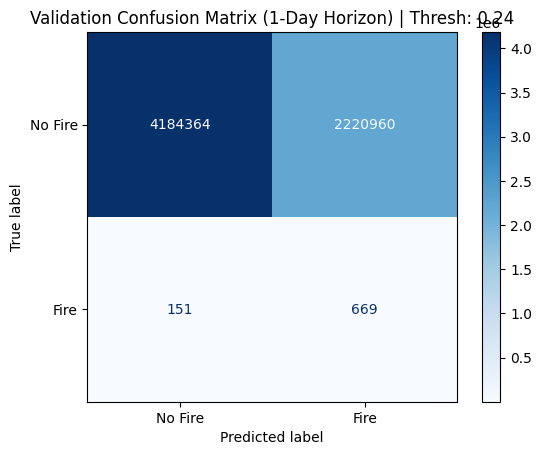


 HORIZON: 7-DAY PERIOD
 Checkpoint: /home/daves/google_drive/Pessoal/Notebooks/Queimadas/Production/Models/final_model_7d_period.pth
[INFO] Weights loaded successfully.
[INFO] Validation set: 391 patches  |  13 batches

 -> Optimal Threshold: 0.45  |  J-Stat: 0.4997

--- CLASSIFICATION REPORT (7-DAY PERIOD) | Threshold: 0.45 ---
              precision    recall  f1-score   support

 No Fire (0)       1.00      0.76      0.87   6400981
    Fire (1)       0.00      0.74      0.00      5163

    accuracy                           0.76   6406144
   macro avg       0.50      0.75      0.44   6406144
weighted avg       1.00      0.76      0.86   6406144

 -> False Positive Rate (FPR): 0.2376 (23.76%)  [False Alarms]
 -> False Negative Rate (FNR): 0.2626 (26.26%)  [Missed Fires]


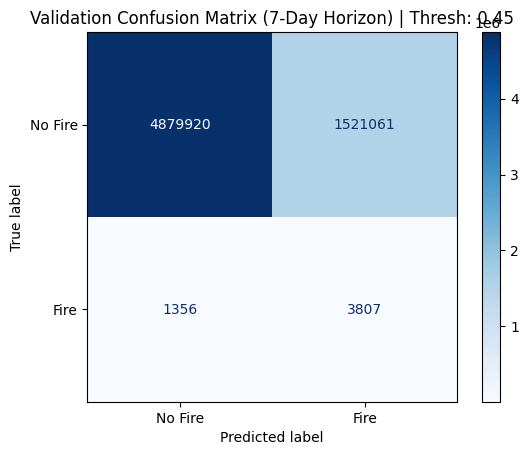


 HORIZON: 14-DAY PERIOD
 Checkpoint: /home/daves/google_drive/Pessoal/Notebooks/Queimadas/Production/Models/final_model_14d_period.pth
[INFO] Weights loaded successfully.
[INFO] Validation set: 391 patches  |  13 batches

 -> Optimal Threshold: 0.56  |  J-Stat: 0.5511

--- CLASSIFICATION REPORT (14-DAY PERIOD) | Threshold: 0.56 ---
              precision    recall  f1-score   support

 No Fire (0)       1.00      0.80      0.89   6390683
    Fire (1)       0.01      0.76      0.02     15461

    accuracy                           0.79   6406144
   macro avg       0.50      0.78      0.45   6406144
weighted avg       1.00      0.79      0.88   6406144

 -> False Positive Rate (FPR): 0.2049 (20.49%)  [False Alarms]
 -> False Negative Rate (FNR): 0.2440 (24.40%)  [Missed Fires]


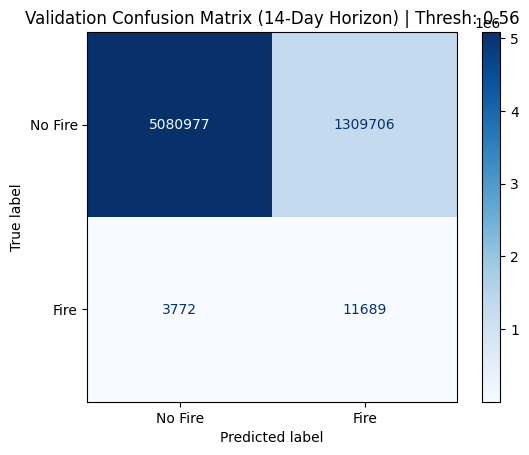


 HORIZON: 30-DAY PERIOD
 Checkpoint: /home/daves/google_drive/Pessoal/Notebooks/Queimadas/Production/Models/final_model_30d_period.pth
[INFO] Weights loaded successfully.
[INFO] Validation set: 391 patches  |  13 batches

 -> Optimal Threshold: 0.60  |  J-Stat: 0.5307

--- CLASSIFICATION REPORT (30-DAY PERIOD) | Threshold: 0.60 ---
              precision    recall  f1-score   support

 No Fire (0)       1.00      0.72      0.84   6380169
    Fire (1)       0.01      0.81      0.02     25975

    accuracy                           0.72   6406144
   macro avg       0.51      0.77      0.43   6406144
weighted avg       0.99      0.72      0.83   6406144

 -> False Positive Rate (FPR): 0.2795 (27.95%)  [False Alarms]
 -> False Negative Rate (FNR): 0.1898 (18.98%)  [Missed Fires]


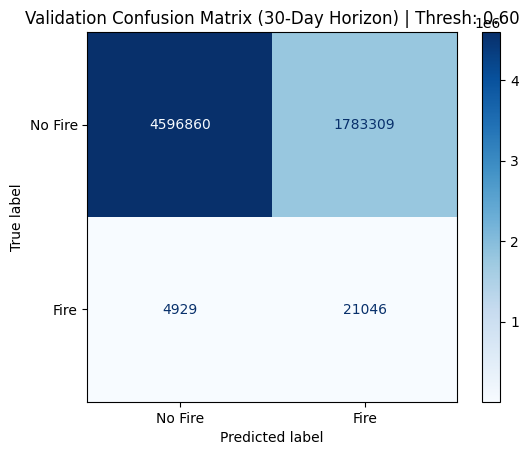


######################################################################
 STEP 4B COMPLETE. Proceed to Step 5 for spatial prediction.
######################################################################



In [4]:
# =====================================================================
# STEP 4B: VALIDATION STATISTICS FROM SAVED MODELS (SKIP-TRAINING MODE)
# =====================================================================

# =====================================================================
# Run this block instead of Step 4 when models are already trained.
# Loads .pth files from the Models directory and reproduces the full
# J-Stat threshold calibration + classification report for each horizon.
# =====================================================================

print(f"\n{'#'*70}\n STEP 4B: LOADING SAVED MODELS & COMPUTING VALIDATION STATISTICS\n{'#'*70}")

import glob
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import gc

# ── Architecture & dataset must be re-declared when Step 4 is skipped ──

EXPECTED_CHANNELS = (5 * 14) + 5

class LazyDiskDataset(Dataset):
    def __init__(self, directory, phase, seq_len=14, horizon=7):
        self.files = glob.glob(os.path.join(directory, f"{phase}_patch_*.pt"))
        self.seq_len = seq_len
        self.horizon = horizon

    def __len__(self): return len(self.files)

    def __getitem__(self, idx):
        data = torch.load(self.files[idx], weights_only=False)
        time_steps = data['time_steps']
        max_start = time_steps - self.seq_len - self.horizon
        t_idx = np.random.randint(0, max_start)

        env_chunks = [data['env'][var_idx, t_idx : t_idx+self.seq_len] for var_idx in range(5)]
        static_chunks = [
            data['lulc'][t_idx+self.seq_len-1].unsqueeze(0),
            data['roads'].unsqueeze(0),
            data['dem'].unsqueeze(0),
            data['slope'].unsqueeze(0),
            data['aspect'].unsqueeze(0)
        ]
        inputs = torch.cat(env_chunks + static_chunks, dim=0)

        future_window = data['fire'][t_idx + self.seq_len : t_idx + self.seq_len + self.horizon]
        target = future_window.max(dim=0)[0].unsqueeze(0)
        return inputs, target


class DeepFireCNN(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 1, 1)
        )
    def forward(self, x): return self.net(x)


# ── Horizons to evaluate ────────────────────────────────────────────
horizons = [1, 7, 14, 30]

for h in horizons:
    model_path = os.path.join(model_dir, f"final_model_{h}d_period.pth")

    if not os.path.exists(model_path):
        print(f"\n[WARNING] Model not found for {h}-day horizon: {model_path}")
        print("         Skipping. Run Step 4 first to produce this checkpoint.")
        continue

    print(f"\n{'='*60}")
    print(f" HORIZON: {h}-DAY PERIOD")
    print(f" Checkpoint: {model_path}")
    print(f"{'='*60}")

    # ── Load model weights ──────────────────────────────────────────
    model_eval = DeepFireCNN(EXPECTED_CHANNELS).to(device)
    state_dict = torch.load(model_path, map_location=device, weights_only=True)
    clean_state_dict = {k.replace('_orig_mod.', ''): v for k, v in state_dict.items()}
    model_eval.load_state_dict(clean_state_dict)
    model_eval.eval()
    print(f"[INFO] Weights loaded successfully.")

    # ── Build validation DataLoader ─────────────────────────────────
    ds_val = LazyDiskDataset(sliced_dir, phase="val", seq_len=14, horizon=h)
    dl_val = DataLoader(ds_val, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
    print(f"[INFO] Validation set: {len(ds_val)} patches  |  {len(dl_val)} batches")

    # ── Forward pass over validation set ───────────────────────────
    all_targets = []
    all_probs   = []

    with torch.no_grad():
        for bx, by in dl_val:
            bx = bx.to(device, non_blocking=True)
            with torch.amp.autocast('cuda'):
                logits = model_eval(bx)
            probs = torch.sigmoid(logits).cpu().numpy()
            all_targets.extend(by.numpy().flatten())
            all_probs.extend(probs.flatten())
            del bx, by, logits, probs

    all_targets = np.array(all_targets)
    all_probs   = np.array(all_probs)

    # ── J-Stat threshold sweep ──────────────────────────────────────
    best_thresh  = 0.5
    best_j       = -1.0
    best_metrics = {}

    for t in np.arange(0.01, 1.0, 0.01):
        pb = (all_probs >= t).astype(int)

        tp = np.sum((pb == 1) & (all_targets == 1))
        fp = np.sum((pb == 1) & (all_targets == 0))
        fn = np.sum((pb == 0) & (all_targets == 1))
        tn = np.sum((pb == 0) & (all_targets == 0))

        rec = tp / (tp + fn + 1e-8)
        fpr = fp / (fp + tn + 1e-8)
        j_stat = rec - fpr

        if j_stat > best_j:
            best_j, best_thresh = j_stat, t
            best_metrics = {'rec': rec, 'fpr': fpr, 'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn}

    print(f"\n -> Optimal Threshold: {best_thresh:.2f}  |  J-Stat: {best_j:.4f}")

    all_preds = (all_probs >= best_thresh).astype(int)

    # ── Classification report ───────────────────────────────────────
    print(f"\n--- CLASSIFICATION REPORT ({h}-DAY PERIOD) | Threshold: {best_thresh:.2f} ---")
    print(classification_report(all_targets, all_preds,
                                target_names=["No Fire (0)", "Fire (1)"],
                                zero_division=0))
    print(f" -> False Positive Rate (FPR): {best_metrics['fpr']:.4f} "
          f"({best_metrics['fpr']*100:.2f}%)  [False Alarms]")
    print(f" -> False Negative Rate (FNR): {(1 - best_metrics['rec']):.4f} "
          f"({(1 - best_metrics['rec'])*100:.2f}%)  [Missed Fires]")

    # ── Confusion matrix plot ───────────────────────────────────────
    cm   = np.array([[best_metrics['tn'], best_metrics['fp']],
                     [best_metrics['fn'], best_metrics['tp']]])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Fire", "Fire"])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f"Validation Confusion Matrix ({h}-Day Horizon) | Thresh: {best_thresh:.2f}")
    plt.show()

    # ── Cleanup ─────────────────────────────────────────────────────
    del model_eval, ds_val, dl_val, all_targets, all_preds, all_probs, state_dict, clean_state_dict
    gc.collect()
    torch.cuda.empty_cache()

print(f"\n{'#'*70}")
print(" STEP 4B COMPLETE. Proceed to Step 5 for spatial prediction.")
print(f"{'#'*70}\n")

In [14]:
# =====================================================================
# STEP 5: MULTI-HORIZON SPATIAL PREDICTION (JPG 1200 DPI + TIF + HTML)
# =====================================================================
print(f"\n{'#'*70}\n STEP 5: SPATIAL PREDICTION FOR ALL 4 RISK WINDOWS\n{'#'*70}")

# Define directories
today_str = datetime.now().strftime('%Y_%m_%d')
pred_dir = "/home/daves/google_drive/Pessoal/Notebooks/Queimadas/Production/Prediction"
os.makedirs(pred_dir, exist_ok=True)

# -----------------------------------------------------------------
# 0. DYNAMICALLY LOAD THE LATEST SLICED PATCH
# -----------------------------------------------------------------
print("[INFO] Searching for the latest temporal data patch...")
search_pattern = os.path.join(sliced_dir, "val_patch_2026_*.pt")
list_of_files = glob.glob(search_pattern)

if not list_of_files:
    raise FileNotFoundError(f"[ERROR] No patch files found matching pattern: {search_pattern}")

latest_file = max(list_of_files, key=os.path.getmtime)
print(f"       -> Loaded latest patch: {os.path.basename(latest_file)}")

ref_tif = os.path.join(data_dir, 'ERA5_Temp_2026.tif')

# -----------------------------------------------------------------
# 1. GEOSPATIAL DATA LOADING & OPTIMIZATION (SHAPEFILES)
# -----------------------------------------------------------------
print("[INFO] Loading and optimizing Shapefiles for Mato Grosso...")

path_mun = "/home/daves/google_drive/Pessoal/Notebooks/Queimadas/Queimadas_Data/MT_Municipios_2022/MT_Municipios_2022.shp"
path_fed = "/home/daves/google_drive/Pessoal/Notebooks/Queimadas/Queimadas_Data/Federal Highways/SNV_202410A.shp"
path_est = "/home/daves/google_drive/Pessoal/Notebooks/Queimadas/Queimadas_Data/State Highways/INTERMAT_TRA_SISTEMA_VIARIO_L.shp"

# Load, simplify and clean Municipalities
mt_gdf = gpd.read_file(path_mun).to_crs(epsg=4326)
mt_gdf['geometry'] = mt_gdf['geometry'].simplify(tolerance=0.005, preserve_topology=True)
mt_gdf = mt_gdf.dropna(subset=['geometry'])
mt_gdf = mt_gdf[~mt_gdf.geometry.is_empty]
city_col = 'NM_MUN' if 'NM_MUN' in mt_gdf.columns else mt_gdf.columns[0]
mt_gdf = mt_gdf[[city_col, 'geometry']]

print("       -> Processing state boundary and clipping highways...")
mt_state_boundary = mt_gdf.dissolve()
mt_geom = [mapping(mt_state_boundary.geometry.iloc[0])] 

# Load, clip, simplify and clean Federal Highways
fed_gdf = gpd.clip(gpd.read_file(path_fed).to_crs(epsg=4326), mt_state_boundary)
fed_gdf['geometry'] = fed_gdf['geometry'].simplify(tolerance=0.005, preserve_topology=True)
fed_gdf = fed_gdf.dropna(subset=['geometry'])
fed_gdf = fed_gdf[~fed_gdf.geometry.is_empty]
fed_gdf = fed_gdf[['geometry']]

# Load, clip, simplify and clean State Highways
state_gdf = gpd.clip(gpd.read_file(path_est).to_crs(epsg=4326), mt_state_boundary)
state_gdf['geometry'] = state_gdf['geometry'].simplify(tolerance=0.005, preserve_topology=True)
state_gdf = state_gdf.dropna(subset=['geometry'])
state_gdf = state_gdf[~state_gdf.geometry.is_empty]
state_gdf = state_gdf[['geometry']]

# -----------------------------------------------------------------
# 2. NEURAL NETWORK INFERENCE (GENERATING TIF RISK MAPS)
# -----------------------------------------------------------------
horizons = [1, 7, 14, 30]
pred_maps = {}

if not os.path.exists(ref_tif):
    print(f"[ERROR] Required reference data missing: {ref_tif}")
else:
    print(f"\n[INFO] Extracting temporal sequence and running DeepFireCNN models...")
    data = torch.load(latest_file)
    time_steps = data['time_steps']
    seq_len = 14
    t_idx = time_steps - seq_len
    
    env_chunks = [data['env'][var_idx, t_idx : t_idx+seq_len] for var_idx in range(5)]
    static_chunks = [
        data['lulc'][t_idx+seq_len-1].unsqueeze(0), 
        data['roads'].unsqueeze(0), 
        data['dem'].unsqueeze(0),
        data['slope'].unsqueeze(0),
        data['aspect'].unsqueeze(0)
    ]
    x_input = torch.cat(env_chunks + static_chunks, dim=0).unsqueeze(0).to(device)

    with rasterio.open(ref_tif) as src:
        meta = src.meta.copy()
        meta.update(dtype=rasterio.float32, count=1, nodata=np.nan) 
        map_bounds = [[src.bounds.bottom, src.bounds.left], [src.bounds.top, src.bounds.right]]

    for h in horizons:
        model_path = os.path.join(model_dir, f"final_model_{h}d_period.pth")
        if not os.path.exists(model_path): 
            print(f"       [!] Warning: Model for {h}-day horizon not found at {model_path}. Skipping.")
            continue
            
        print(f"       -> Executing forward pass for the {h}-day period...")
        inference_model = DeepFireCNN(EXPECTED_CHANNELS).to(device)
        state_dict = torch.load(model_path, map_location=device, weights_only=True)
        clean_state_dict = {k.replace('_orig_mod.', ''): v for k, v in state_dict.items()}
        inference_model.load_state_dict(clean_state_dict)
        inference_model.eval()
        
        with torch.no_grad():
            with torch.amp.autocast('cuda'):
                raw_logits = inference_model(x_input)
            probabilities = torch.sigmoid(raw_logits).squeeze().cpu().numpy()
        
        output_tif = os.path.join(pred_dir, f"Fire_Risk_{h}Days_Generated_{today_str}.tif")
        
        with rasterio.open(output_tif, 'w', **meta) as dst:
            dst.write(probabilities.astype(np.float32), 1)
            
        with rasterio.open(output_tif) as src_clip:
            out_image, out_transform = mask(src_clip, mt_geom, crop=True, filled=False)
            out_meta = src_clip.meta.copy()
            
        out_meta.update({"driver": "GTiff", "height": out_image.shape[1], "width": out_image.shape[2], "transform": out_transform})
        
        with rasterio.open(output_tif, "w", **out_meta) as dest:
            dest.write(out_image)
        
        pred_maps[h] = out_image[0]
            
        del inference_model, raw_logits, state_dict, clean_state_dict
        gc.collect()
        torch.cuda.empty_cache()

# -----------------------------------------------------------------
# 3. EXPORTING: 1200 DPI JPG & INTERACTIVE HTML
# -----------------------------------------------------------------
if len(pred_maps) > 0:
    print("\n[INFO] Assembling and saving visualizations...")
    
    # Map elements remain in Portuguese
    titles_pt = {1: "Amanhã (24h)", 7: "Próximos 7 Dias", 14: "Próximos 14 Dias", 30: "Próximos 30 Dias"}
    
    # Custom Gradient: Blue (0) -> Yellow (0.5) -> Red (1)
    cmap_base = mcolors.LinearSegmentedColormap.from_list("BlueYellowRed", ["blue", "yellow", "red"])
    
    # 3.1 SAVING THE STATIC JPG GRID (1200 DPI)
    print("       -> Generating ultra-high resolution JPG image (1x4 Grid) at 1200 DPI...")
    cmap_jpg = cmap_base.copy()
    cmap_jpg.set_bad(color='white') 
    
    fig, axes = plt.subplots(1, 4, figsize=(24, 6))
    for idx, h in enumerate(horizons):
        if h in pred_maps:
            ax = axes[idx]
            im = ax.imshow(pred_maps[h], cmap=cmap_jpg, vmin=0, vmax=1)
            ax.set_title(titles_pt[h], fontsize=14, fontweight='bold', pad=10)
            ax.axis('off')
    
    cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.03])
    cbar = fig.colorbar(im, cbar_ax, orientation='horizontal')
    cbar.set_label("Probabilidade Acumulada de Fogo (0.0 - 1.0)", fontsize=12, labelpad=5) # Portuguese Map Label
    plt.suptitle(f"Evolução Temporal do Risco de Queimadas em MT", fontsize=16, fontweight='bold', y=0.98) # Portuguese Title
    plt.subplots_adjust(bottom=0.15, top=0.85, wspace=0.1)
    
    # Exporting as JPG with 1200 DPI
    jpg_path = os.path.join(pred_dir, f"Painel_Evolutivo_Completo_{today_str}.jpg")
    plt.savefig(jpg_path, dpi=1200, bbox_inches='tight', facecolor='white', format='jpg')
    print(f"       [+] Saved: {jpg_path}")
    
    # IMPORTANT: plt.close(fig) prevents the script from halting!
    plt.close(fig) 

    # 3.2 SAVING THE INTERACTIVE HTML MAP (Folium)
    print("       -> Generating Interactive Web Map (HTML)...")
    cmap_html = cmap_base.copy()
    cmap_html.set_bad(alpha=0.0) 
    
    mt_center = [-12.64, -55.42]
    interactive_map = folium.Map(location=mt_center, zoom_start=6, tiles="CartoDB positron", control_scale=True)
    
    # --- PROBABILITY LEGEND ---
    colormap = cm.LinearColormap(colors=['blue', 'yellow', 'red'], vmin=0.0, vmax=1.0)
    colormap.caption = 'Probabilidade Acumulada de Fogo' # Portuguese Map Label
    interactive_map.add_child(colormap)
    # --------------------------
    
    for h in horizons:
        if h in pred_maps:
            masked_data = np.ma.masked_invalid(pred_maps[h])
            colorized = cmap_html(masked_data)
            img_data = np.uint8(colorized * 255)
            img_pil = Image.fromarray(img_data)
            
            buffered = io.BytesIO()
            img_pil.save(buffered, format="PNG")
            img_b64 = base64.b64encode(buffered.getvalue()).decode()
            
            folium.raster_layers.ImageOverlay(
                image=f"data:image/png;base64,{img_b64}",
                bounds=map_bounds,
                opacity=0.65,
                name=f'Risco de Fogo: {titles_pt[h]}', # Portuguese Layer Name
                show=(h == 1)
            ).add_to(interactive_map)

    # Adding Vector Layers
    
    # 1. Municipalities
    folium.GeoJson(
        mt_gdf, 
        name="Limites Municipais", # Portuguese Layer Name
        style_function=lambda x: {'color': '#333333', 'weight': 0.5, 'fillOpacity': 0},
        tooltip=folium.GeoJsonTooltip(fields=[city_col], aliases=['Município:'], style="font-weight: bold; background: white;")
    ).add_to(interactive_map)
    
    # 2. Federal Highways (Bolder Green lines)
    folium.GeoJson(
        fed_gdf, 
        name="Rodovias Federais (BR)", # Portuguese Layer Name
        style_function=lambda x: {'color': 'green', 'weight': 1}
    ).add_to(interactive_map)
    
    # 3. State Highways (Bolder Magenta lines)
    folium.GeoJson(
        state_gdf, 
        name="Rodovias Estaduais (MT)", # Portuguese Layer Name
        style_function=lambda x: {'color': 'magenta', 'weight': 1}, 
        show=False
    ).add_to(interactive_map)
    
    folium.LayerControl(collapsed=False).add_to(interactive_map)
    
    html_path = os.path.join(pred_dir, f"Mapa_Interativo_Risco_{today_str}.html")
    interactive_map.save(html_path)
    print(f"       [+] Saved: {html_path}")
    
    # 3.3 VALIDATING GOOGLE DRIVE SYNC
    print("\n[SYNC VERIFICATION]")
    if os.path.exists(jpg_path) and os.path.exists(html_path):
        print(" [+] Python successfully confirmed the physical creation of the JPG and HTML files in the WSL directory.")
    else:
        print(" [ERROR] A failure occurred while trying to verify the files on Drive.")

else:
    print("[ERROR] No predictions were generated.")

del x_input, data, pred_maps
gc.collect()
torch.cuda.empty_cache()


######################################################################
 STEP 5: SPATIAL PREDICTION FOR ALL 4 RISK WINDOWS
######################################################################
[INFO] Searching for the latest temporal data patch...
       -> Loaded latest patch: val_patch_2026_68.pt
[INFO] Loading and optimizing Shapefiles for Mato Grosso...
       -> Processing state boundary and clipping highways...

[INFO] Extracting temporal sequence and running DeepFireCNN models...
       -> Executing forward pass for the 1-day period...
       -> Executing forward pass for the 7-day period...
       -> Executing forward pass for the 14-day period...
       -> Executing forward pass for the 30-day period...

[INFO] Assembling and saving visualizations...
       -> Generating ultra-high resolution JPG image (1x4 Grid) at 1200 DPI...
       [+] Saved: /home/daves/google_drive/Pessoal/Notebooks/Queimadas/Production/Prediction/Painel_Evolutivo_Completo_2026_06_15.jpg
       -> Genera

In [15]:
# =====================================================================
# STEP 6: MANUAL VRAM FLUSH & GARBAGE COLLECTION
# =====================================================================
print("Clearing residual memory and releasing GPU...")

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    
print("[SUCCESS] VRAM released. The system is ready for a new execution or shutdown.")

Clearing residual memory and releasing GPU...
[SUCCESS] VRAM released. The system is ready for a new execution or shutdown.
